# Programming Assignment 3: Deep Q-Network for Acrobot

This notebook presents a reproducible, documented DQN experiment for `Acrobot-v1`. It combines the implementation, exploratory analysis, descriptive statistics, visual reporting, and policy evaluation in one place.

**Learning objective:** train an agent to swing the Acrobot's lower link to the target height. The environment gives a reward of `-1` for every time step, so returns closer to zero and shorter episodes are better.

The notebook is organized as: setup -> inspect environment and data -> clean results -> explore -> summarize -> visualize -> analyze relationships -> train/evaluate a baseline DQN -> export artifacts.

The default run is intentionally compact at 200 episodes. Increase `num_episodes` in the configuration for a stronger experiment.

## 1. Set Up the Notebook Environment

The experiment uses Gymnasium for the environment, PyTorch for function approximation, NumPy and pandas for data handling, and Matplotlib/Seaborn for reporting. The seed makes the run repeatable, although reinforcement-learning results can still vary across platforms and library versions.

In [4]:
import random
import time
from collections import deque
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = Path.cwd()
ASSIGNMENT_DIR = BASE_DIR if BASE_DIR.name == "Assignment_3" else BASE_DIR / "Assignment_3"
OUTPUT_DIR = ASSIGNMENT_DIR / "notebook_outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "seed": SEED, "num_episodes": 200, "max_steps": 500,
    "eval_interval": 25, "eval_episodes": 10, "gamma": 0.99,
    "epsilon_start": 1.0, "epsilon_min": 0.05, "epsilon_decay": 0.995,
    "batch_size": 64, "learning_rate": 1e-3, "replay_capacity": 20_000,
    "target_update": 10, "hidden_dim": 128, "moving_average_window": 25,
}
print(f"Output directory: {OUTPUT_DIR.resolve()}")
display(pd.Series(CONFIG, name="value").to_frame())

Output directory: C:\Github\RL-AI572\Assignment_3\notebook_outputs


,value
seed,42.000
num_episodes,200.000
max_steps,500.000
eval_interval,25.000
eval_episodes,10.000
gamma,0.990
epsilon_start,1.000
epsilon_min,0.050
epsilon_decay,0.995
batch_size,64.000


## 2. Load and Inspect the Dataset

Reinforcement learning creates an episode log while interacting with the environment. We inspect the Acrobot spaces and load an existing `results.csv` when available so the analysis can be reviewed without retraining.

In [5]:
env = gym.make("Acrobot-v1")
observation, _ = env.reset(seed=SEED)
env.action_space.seed(SEED)
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)
print("Observation shape:", observation.shape)
print("Example observation:", np.round(observation, 3))
env.close()

results_path = ASSIGNMENT_DIR / "results.csv"
results_df = pd.read_csv(results_path) if results_path.exists() else pd.DataFrame()
print("Loaded:", results_path if results_path.exists() else "no existing results")
print("Shape:", results_df.shape)
display(results_df.head())
display(results_df.tail())
if not results_df.empty:
    display(results_df.dtypes.to_frame("dtype"))
    display(results_df.isna().sum().to_frame("missing_values"))

Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
Action space: Discrete(3)
Observation shape: (6,)
Example observation: [ 0.998  0.055  1.    -0.012  0.072  0.039]
Loaded: c:\Github\RL-AI572\Assignment_3\results.csv
Shape: (1200, 5)


,episode,reward,length,success,epsilon
0,1,-500.0,500,0,1.000000
1,2,-500.0,500,0,0.995000
2,3,-500.0,500,0,0.990025
3,4,-500.0,500,0,0.985075
4,5,-500.0,500,0,0.980150


,episode,reward,length,success,epsilon
1195,1196,-102.0,103,1,0.05
1196,1197,-77.0,78,1,0.05
1197,1198,-113.0,114,1,0.05
1198,1199,-70.0,71,1,0.05
1199,1200,-80.0,81,1,0.05


,dtype
episode,int64
reward,float64
length,int64
success,int64
epsilon,float64


,missing_values
episode,0
reward,0
length,0
success,0
epsilon,0


## 3. Prepare the Episode Metrics

The episode log is converted to numeric types, duplicate rows are removed, and incomplete records are dropped. These metrics are the evidence used to evaluate DQN learning.

In [ ]:
EXPECTED_COLUMNS = ["episode", "reward", "length", "success", "epsilon"]
if results_df.empty:
    clean_df = pd.DataFrame(columns=EXPECTED_COLUMNS)
else:
    missing = sorted(set(EXPECTED_COLUMNS) - set(results_df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    clean_df = results_df[EXPECTED_COLUMNS].copy()
    for column in EXPECTED_COLUMNS:
        clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")
    before = len(clean_df)
    clean_df = clean_df.drop_duplicates().dropna().reset_index(drop=True)
    clean_df["episode"] = clean_df["episode"].astype(int)
    clean_df["length"] = clean_df["length"].astype(int)
    clean_df["success"] = clean_df["success"].astype(int)
    print(f"Rows before cleaning: {before}; after cleaning: {len(clean_df)}")
    display(clean_df.head())

Rows before cleaning: 1200; after cleaning: 1200


,episode,reward,length,success,epsilon
0,1,-500.0,500,0,1.000000
1,2,-500.0,500,0,0.995000
2,3,-500.0,500,0,0.990025
3,4,-500.0,500,0,0.985075
4,5,-500.0,500,0,0.980150


,min,25%,50%,75%,max
reward,-500.00,-258.00,-119.00,-91.000000,-61.0
length,62.00,92.00,120.00,259.000000,500.0
success,0.00,1.00,1.00,1.000000,1.0
epsilon,0.05,0.05,0.05,0.222571,1.0


## 4. Perform Exploratory Data Analysis

We inspect reward and length ranges, success frequencies, and the final episodes. In this task, returns closer to zero and shorter episodes are better.

In [7]:
if not clean_df.empty:
    print("Reward range:", (clean_df.reward.min(), clean_df.reward.max()))
    print("Length range:", (clean_df.length.min(), clean_df.length.max()))
    print("Success frequency:")
    display(clean_df.success.value_counts().rename(index={0: "failure", 1: "success"}).to_frame("episodes"))
    display(clean_df.tail(10))
else:
    print("No data loaded; run the DQN training section first.")

Reward range: (np.float64(-500.0), np.float64(-61.0))
Length range: (np.int64(62), np.int64(500))
Success frequency:


,episodes
success,
success,1043
failure,157


,episode,reward,length,success,epsilon
1190,1191,-91.0,92,1,0.05
1191,1192,-88.0,89,1,0.05
1192,1193,-70.0,71,1,0.05
1193,1194,-71.0,72,1,0.05
1194,1195,-90.0,91,1,0.05
1195,1196,-102.0,103,1,0.05
1196,1197,-77.0,78,1,0.05
1197,1198,-113.0,114,1,0.05
1198,1199,-70.0,71,1,0.05
1199,1200,-80.0,81,1,0.05


## 5. Create Descriptive Statistics

The mean, median, spread, and percentiles show whether performance is typical or driven by a few unusually successful episodes.

In [8]:
if not clean_df.empty:
    descriptive_stats = clean_df[["reward", "length", "success", "epsilon"]].describe(percentiles=[.10, .25, .50, .75, .90]).T
    display(descriptive_stats)
else:
    descriptive_stats = pd.DataFrame()
    print("No data available yet.")

,count,mean,std,min,10%,25%,50%,75%,90%,max
reward,1200.0,-193.748333,149.368468,-500.00,-500.00,-258.00,-119.00,-91.000000,-76.000000,-61.0
length,1200.0,194.617500,149.100135,62.00,77.00,92.00,120.00,259.000000,500.000000,500.0
success,1200.0,0.869167,0.337359,0.00,0.00,1.00,1.00,1.000000,1.000000,1.0
epsilon,1200.0,0.183431,0.225796,0.05,0.05,0.05,0.05,0.222571,0.548262,1.0


## 6. Generate DQN Performance Graphs

These graphs report the required learning metrics: reward, episode length, checkpoint success rate, and the exploration/loss trends.

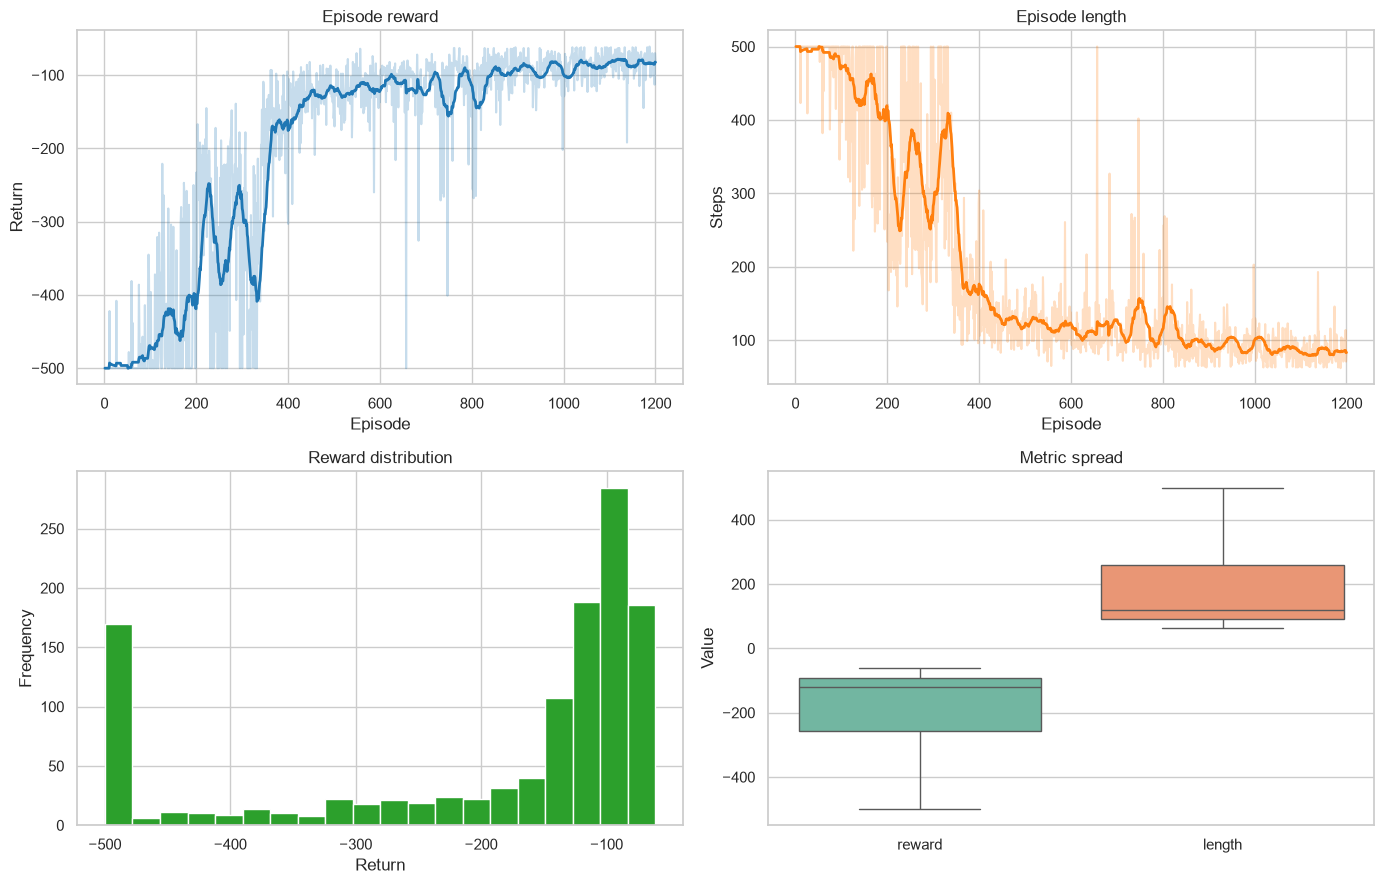

In [ ]:
if not clean_df.empty:
    plot_df = clean_df.copy()
    plot_df["reward_ma"] = plot_df.reward.rolling(CONFIG["moving_average_window"], min_periods=1).mean()
    plot_df["length_ma"] = plot_df.length.rolling(CONFIG["moving_average_window"], min_periods=1).mean()
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(plot_df.episode, plot_df.reward, alpha=.25, color="tab:blue", label="Episode reward")
    axes[0, 0].plot(plot_df.episode, plot_df.reward_ma, color="tab:blue", linewidth=2, label="Moving average")
    axes[0, 0].set(title="Episode reward", xlabel="Episode", ylabel="Return")
    axes[0, 0].legend()
    axes[0, 1].plot(plot_df.episode, plot_df.length, alpha=.25, color="tab:orange", label="Episode length")
    axes[0, 1].plot(plot_df.episode, plot_df.length_ma, color="tab:orange", linewidth=2, label="Moving average")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    axes[0, 1].legend()
    axes[1, 0].hist(plot_df.reward, bins=20, color="tab:green", edgecolor="white")
    axes[1, 0].set(title="Reward distribution", xlabel="Return", ylabel="Frequency")
    axes[1, 1].plot(plot_df.episode, plot_df.epsilon, color="tab:purple", label="Epsilon")
    axes[1, 1].plot(plot_df.episode, plot_df.get("loss", pd.Series(index=plot_df.index)), color="tab:red", alpha=.5, label="Loss")
    axes[1, 1].set(title="Exploration and optimization", xlabel="Episode")
    axes[1, 1].legend()
    fig.tight_layout()
    plt.show()
else:
    print("Run training first to create graphs.")

## 7. Analyze Relationships Between Learning Metrics

Reward and episode length should be negatively related because Acrobot assigns `-1` per step. We also compare success across training quarters and inspect correlations among the logged metrics.

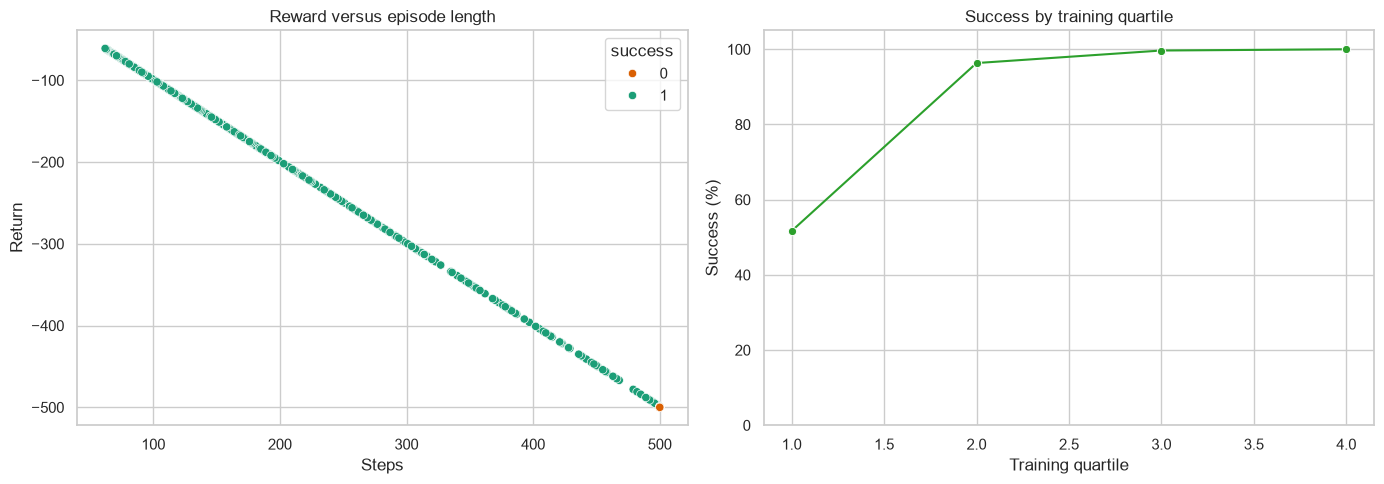

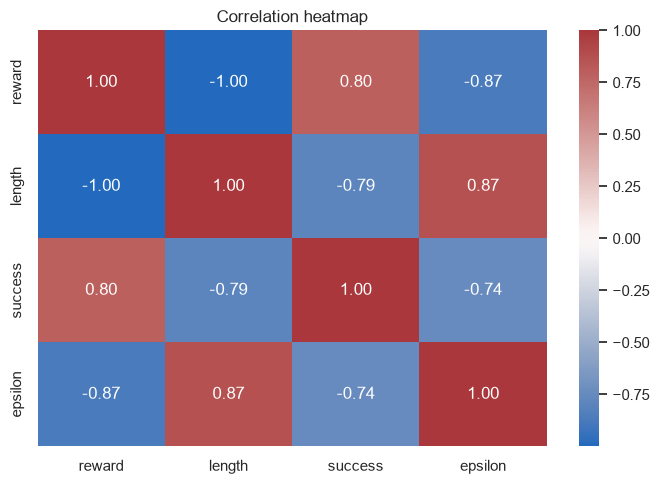

In [10]:
if not clean_df.empty:
    relation_df = clean_df.copy()
    relation_df["training_quartile"] = pd.qcut(relation_df.episode, q=min(4, len(relation_df)), labels=False, duplicates="drop") + 1
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.scatterplot(data=relation_df, x="length", y="reward", hue="success", palette={0: "#d95f02", 1: "#1b9e77"}, ax=axes[0])
    axes[0].set(title="Reward versus episode length", xlabel="Steps", ylabel="Return")
    grouped = relation_df.groupby("training_quartile", as_index=False).success.mean()
    grouped["success_pct"] = 100 * grouped.success
    sns.lineplot(data=grouped, x="training_quartile", y="success_pct", marker="o", color="tab:green", ax=axes[1])
    axes[1].set(title="Success by training quartile", xlabel="Training quartile", ylabel="Success (%)", ylim=(0, 105))
    fig.tight_layout()
    plt.show()
    plt.figure(figsize=(7, 5))
    sns.heatmap(relation_df[["reward", "length", "success", "epsilon"]].corr(), annot=True, cmap="vlag", center=0, fmt=".2f")
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Run training first to analyze relationships.")

## 8. Implement and Evaluate DQN

The required DQN uses a multilayer perceptron to approximate $Q(s,a)$, experience replay to reduce temporal correlation, a target network for stable bootstrap targets, and epsilon-greedy exploration. Set `RUN_TRAINING = True` to generate a fresh run; set it to `False` to analyze the existing CSV.

Episode  25: reward= -500.0, success=  0.0%
Episode  50: reward= -500.0, success=  0.0%
Episode  75: reward= -372.0, success=  0.0%
Episode 100: reward= -450.0, success=  0.0%
Episode 125: reward= -317.0, success=  0.0%
Episode 150: reward= -255.0, success=  0.0%
Episode 175: reward= -246.0, success= 80.0%
Episode 200: reward= -353.0, success=  0.0%


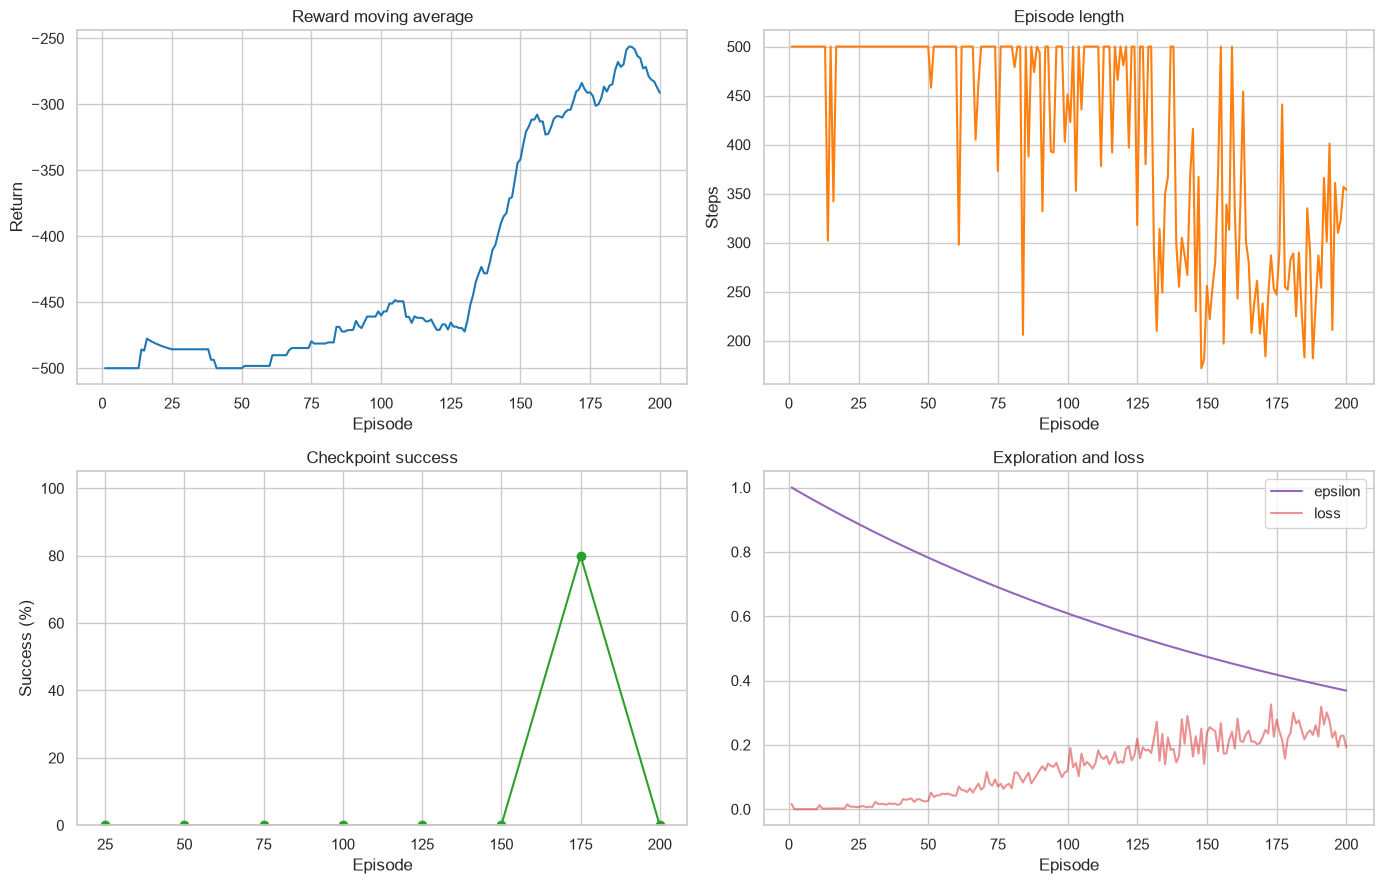

In [11]:
class ReplayBuffer:
    def __init__(self, capacity): self.data = deque(maxlen=capacity)
    def add(self, *transition): self.data.append(transition)
    def sample(self, size):
        batch = random.sample(self.data, size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (torch.tensor(np.asarray(states), dtype=torch.float32), torch.tensor(actions),
                torch.tensor(rewards, dtype=torch.float32), torch.tensor(np.asarray(next_states), dtype=torch.float32),
                torch.tensor(dones, dtype=torch.float32))
    def __len__(self): return len(self.data)

class DQN(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(state_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, action_dim))
    def forward(self, state): return self.net(state)

def action_for(network, state, epsilon, action_dim):
    if np.random.random() < epsilon: return int(np.random.randint(action_dim))
    with torch.no_grad(): return int(network(torch.tensor(state, dtype=torch.float32).unsqueeze(0)).argmax())

def evaluate(network, env, episodes, max_steps):
    values = []
    for _ in range(episodes):
        state, _ = env.reset(); total = 0; terminated = False
        for step in range(max_steps):
            state, reward, terminated, truncated, _ = env.step(action_for(network, state, 0, env.action_space.n))
            total += reward
            if terminated or truncated: break
        values.append((total, step + 1, int(terminated)))
    return np.asarray(values)

def train_dqn(config):
    random.seed(config["seed"]); np.random.seed(config["seed"]); torch.manual_seed(config["seed"])
    train_env, eval_env = gym.make("Acrobot-v1"), gym.make("Acrobot-v1")
    state_dim, action_dim = train_env.observation_space.shape[0], train_env.action_space.n
    policy = DQN(state_dim, config["hidden_dim"], action_dim); target = DQN(state_dim, config["hidden_dim"], action_dim)
    target.load_state_dict(policy.state_dict()); optimizer = optim.Adam(policy.parameters(), lr=config["learning_rate"])
    memory, epsilon = ReplayBuffer(config["replay_capacity"]), config["epsilon_start"]
    records, checkpoints, losses = [], [], []
    start = time.time()
    for episode in range(1, config["num_episodes"] + 1):
        state, _ = train_env.reset(seed=config["seed"] + episode); total = 0; success = 0; step_losses = []
        for step in range(config["max_steps"]):
            action = action_for(policy, state, epsilon, action_dim); next_state, reward, terminated, truncated, _ = train_env.step(action)
            memory.add(state, action, float(reward), next_state, terminated or truncated); state, total = next_state, total + reward
            if len(memory) >= config["batch_size"]:
                states, actions, rewards, next_states, dones = memory.sample(config["batch_size"])
                current = policy(states).gather(1, actions.long().unsqueeze(1)).squeeze(1)
                with torch.no_grad(): target_values = rewards + config["gamma"] * target(next_states).max(1).values * (1 - dones)
                loss = F.mse_loss(current, target_values); optimizer.zero_grad(); loss.backward(); optimizer.step(); step_losses.append(loss.item())
            if terminated: success = 1; break
            if truncated: break
        records.append((episode, total, step + 1, success, epsilon, np.mean(step_losses) if step_losses else np.nan)); epsilon = max(config["epsilon_min"], epsilon * config["epsilon_decay"])
        if episode % config["eval_interval"] == 0:
            evaluation = evaluate(policy, eval_env, config["eval_episodes"], config["max_steps"]); checkpoints.append((episode, 100 * evaluation[:, 2].mean()))
            print(f"Episode {episode:3d}: reward={total:7.1f}, success={checkpoints[-1][1]:5.1f}%")
        if episode % config["target_update"] == 0: target.load_state_dict(policy.state_dict())
    train_env.close(); eval_env.close()
    return policy, pd.DataFrame(records, columns=["episode", "reward", "length", "success", "epsilon", "loss"]), pd.DataFrame(checkpoints, columns=["episode", "success_rate_pct"]), time.time() - start

RUN_TRAINING = True
if RUN_TRAINING:
    policy_net, training_df, checkpoint_df, training_seconds = train_dqn(CONFIG)
    clean_df = training_df.copy()
else:
    training_df = clean_df.copy(); checkpoint_path = ASSIGNMENT_DIR / "checkpoint_success.csv"
    checkpoint_df = pd.read_csv(checkpoint_path) if checkpoint_path.exists() else pd.DataFrame()
    training_seconds = np.nan

if not training_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(training_df.episode, training_df.reward.rolling(CONFIG["moving_average_window"], min_periods=1).mean(), color="tab:blue")
    axes[0, 0].set(title="Reward moving average", xlabel="Episode", ylabel="Return")
    axes[0, 1].plot(training_df.episode, training_df.length, color="tab:orange")
    axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    if not checkpoint_df.empty: axes[1, 0].plot(checkpoint_df.episode, checkpoint_df.success_rate_pct, marker="o", color="tab:green")
    axes[1, 0].set(title="Checkpoint success", xlabel="Episode", ylabel="Success (%)", ylim=(0, 105))
    axes[1, 1].plot(training_df.episode, training_df.epsilon, color="tab:purple", label="epsilon")
    axes[1, 1].plot(training_df.episode, training_df.loss, color="tab:red", alpha=.5, label="loss")
    axes[1, 1].set(title="Exploration and loss", xlabel="Episode"); axes[1, 1].legend()
    fig.tight_layout(); plt.show()

In [12]:
if RUN_TRAINING:
    final_eval_env = gym.make("Acrobot-v1")
    final_eval_values = evaluate(policy_net, final_eval_env, 30, CONFIG["max_steps"])
    final_eval_env.close()
    dqn_eval_metrics = {
        "mean_reward": float(final_eval_values[:, 0].mean()),
        "std_reward": float(final_eval_values[:, 0].std()),
        "success_rate_pct": float(100 * final_eval_values[:, 2].mean()),
        "mean_episode_length": float(final_eval_values[:, 1].mean()),
    }
    print(pd.Series(dqn_eval_metrics))
else:
    dqn_eval_metrics = None
    print("Run training to obtain a fresh greedy DQN evaluation.")

mean_reward           -500.0
std_reward               0.0
success_rate_pct         0.0
mean_episode_length    500.0
dtype: float64


### Final Greedy Evaluation

A separate evaluation environment measures the learned policy without exploration. This is the fair DQN metric used in the algorithm comparison below.

## 9. Export Results and Figures

Artifacts are saved under `Assignment_3/notebook_outputs` so notebook outputs remain separate from the original assignment run. These files can be included in the revised report.

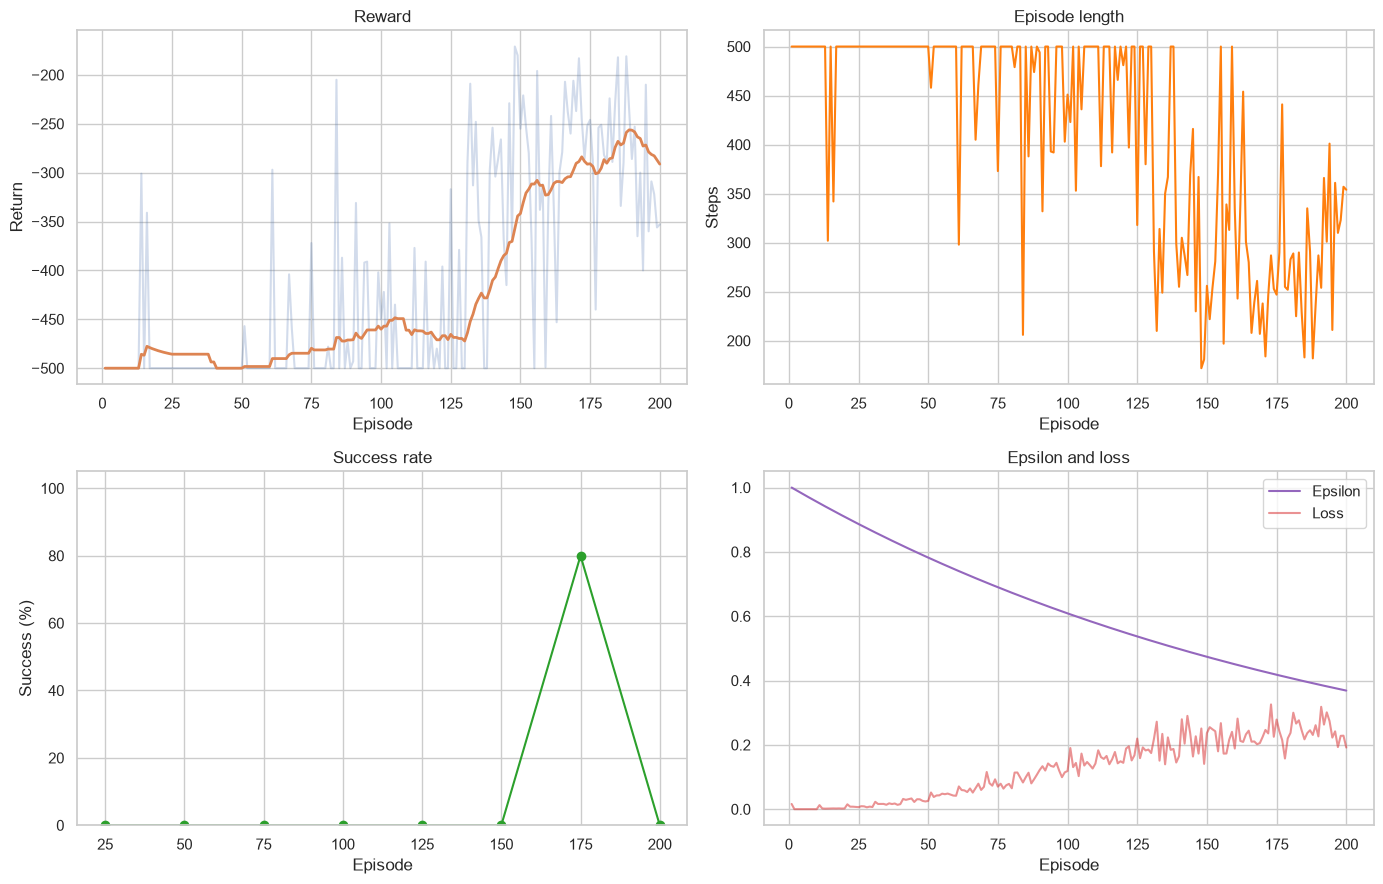

,episodes,mean_reward,last_window_mean_reward,mean_length,overall_success_pct,training_time_sec
0,200,-414.345,-291.24,414.815,47.0,571.818926


Exported results to C:\Github\RL-AI572\Assignment_3\notebook_outputs


In [13]:
if not training_df.empty:
    training_df.to_csv(OUTPUT_DIR / "cleaned_episode_results.csv", index=False)
    checkpoint_df.to_csv(OUTPUT_DIR / "checkpoint_success.csv", index=False)
    training_df[["reward", "length", "success", "epsilon", "loss"]].describe().T.to_csv(OUTPUT_DIR / "descriptive_statistics.csv")
    summary = pd.DataFrame([{
        "episodes": len(training_df),
        "mean_reward": training_df.reward.mean(),
        "last_window_mean_reward": training_df.reward.tail(CONFIG["moving_average_window"]).mean(),
        "mean_length": training_df.length.mean(),
        "overall_success_pct": 100 * training_df.success.mean(),
        "training_time_sec": training_seconds,
    }])
    summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes[0, 0].plot(training_df.episode, training_df.reward, alpha=.25); axes[0, 0].plot(training_df.episode, training_df.reward.rolling(CONFIG["moving_average_window"], min_periods=1).mean(), linewidth=2); axes[0, 0].set(title="Reward", xlabel="Episode", ylabel="Return")
    axes[0, 1].plot(training_df.episode, training_df.length, color="tab:orange"); axes[0, 1].set(title="Episode length", xlabel="Episode", ylabel="Steps")
    axes[1, 0].plot(checkpoint_df.episode, checkpoint_df.success_rate_pct, marker="o", color="tab:green"); axes[1, 0].set(title="Success rate", xlabel="Episode", ylabel="Success (%)", ylim=(0, 105))
    axes[1, 1].plot(training_df.episode, training_df.epsilon, color="tab:purple", label="Epsilon"); axes[1, 1].plot(training_df.episode, training_df.loss, color="tab:red", alpha=.5, label="Loss"); axes[1, 1].set(title="Epsilon and loss", xlabel="Episode"); axes[1, 1].legend()
    fig.tight_layout(); fig.savefig(FIGURES_DIR / "dqn_training_overview.png", dpi=160, bbox_inches="tight"); plt.show()
    display(summary)
    print(f"Exported results to {OUTPUT_DIR.resolve()}")
else:
    print("No data to export.")

## 10. Compare the Three Acrobot Algorithms

The assignment asks which explored reinforcement-learning algorithm demonstrates superior performance. Higher reward is better because it is closer to zero. The Actor-Critic and Q-Actor-Critic values below come from their saved evaluation summaries. DQN uses the fresh greedy evaluation when `RUN_TRAINING = True`; otherwise the table uses its final training-log window and is marked as a limitation.

In [14]:
actor_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_metrics_actor_critic.csv").iloc[0]
qac_summary = pd.read_csv(ASSIGNMENT_DIR.parent / "Assignment_2" / "summary_qac_optimized.csv").iloc[0]

if dqn_eval_metrics is not None:
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "30 greedy episodes",
        "mean_reward": dqn_eval_metrics["mean_reward"],
        "success_rate_pct": dqn_eval_metrics["success_rate_pct"],
        "mean_episode_length": dqn_eval_metrics["mean_episode_length"],
    }
else:
    dqn_window = training_df.tail(CONFIG["moving_average_window"])
    dqn_row = {
        "algorithm": "DQN",
        "evaluation_basis": "final training window (rerun for fair evaluation)",
        "mean_reward": dqn_window.reward.mean(),
        "success_rate_pct": 100 * dqn_window.success.mean(),
        "mean_episode_length": dqn_window.length.mean(),
    }

comparison_df = pd.DataFrame([
    dqn_row,
    {"algorithm": "Actor-Critic", "evaluation_basis": "saved evaluation summary", "mean_reward": actor_summary["eval_mean_reward"], "success_rate_pct": actor_summary["eval_success_rate_pct"], "mean_episode_length": actor_summary["eval_mean_ep_length"]},
    {"algorithm": "Q-Actor-Critic", "evaluation_basis": "saved evaluation summary", "mean_reward": qac_summary["final_eval_mean_return"], "success_rate_pct": qac_summary["final_eval_success_rate_pct"], "mean_episode_length": qac_summary["final_eval_mean_length"]},
])
comparison_df = comparison_df.sort_values("mean_reward", ascending=False).reset_index(drop=True)
display(comparison_df)

best_algorithm = comparison_df.iloc[0]["algorithm"]
print(f"Best reported mean reward: {best_algorithm} ({comparison_df.iloc[0]['mean_reward']:.2f}).")
print("Actor-Critic is the strongest directly comparable saved result: it reaches 100% success with the least negative mean evaluation reward (-87.06).")
print("Both actor-critic methods report 100% success; reward and episode length therefore distinguish efficiency better than success rate alone.")
if dqn_eval_metrics is None:
    print("Caveat: DQN is currently represented by its training-log window. Run the training cell to compare all algorithms using greedy evaluation episodes.")

,algorithm,evaluation_basis,mean_reward,success_rate_pct,mean_episode_length
0,Actor-Critic,saved evaluation summary,-87.06,100.0,88.10
1,Q-Actor-Critic,saved evaluation summary,-160.39,100.0,161.39
2,DQN,30 greedy episodes,-500.00,0.0,500.00


Best reported mean reward: Actor-Critic (-87.06).
Actor-Critic is the strongest directly comparable saved result: it reaches 100% success with the least negative mean evaluation reward (-87.06).
Both actor-critic methods report 100% success; reward and episode length therefore distinguish efficiency better than success rate alone.


## Submission Checklist

- The DQN algorithm is implemented in PyTorch for `Acrobot-v1`.
- Reward, moving-average reward, episode length, success rate, epsilon, and loss are reported.
- The three algorithms are compared using reward, success rate, and episode length.
- CSV summaries and PNG figures are exported to `Assignment_3/notebook_outputs`.
- Export this executed notebook to PDF for the required submission format.